# Centralidades de Katz y Pagerank

Se genera una red de las 30 empresas con mayor capitalizacion de mercado que cotizan en el S&P500.

- Nodos: 30 tickers con mayor market cap del S&P 500.
- Aristas dirigidas: $u\to v$ significa “$u$ provee a $v$”.


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from pathlib import Path

plt.set_cmap("rainbow")

<Figure size 640x480 with 0 Axes>

In [2]:
from typing import List, Tuple

V: List[str] = [
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "GOOG", "AVGO", "META", "TSLA", "BRK.B",
    "JPM", "V", "MA", "WMT", "COST", "ORCL", "LLY", "XOM", "JNJ", "PLTR",
    "BAC", "ABBV", "MU", "HD", "NFLX", "AMD", "PG", "GE", "CVX", "UNH"
]

E: List[Tuple[str, str]] = [
    # semiconductores / hardware / computo
    ("MU", "NVDA"),
    ("AVGO", "AAPL"),

    ("NVDA", "MSFT"), ("NVDA", "AMZN"), ("NVDA", "GOOG"), ("NVDA", "GOOGL"),
    ("NVDA", "ORCL"), ("NVDA", "META"), ("NVDA", "TSLA"),

    ("AMD", "AMZN"), ("AMD", "MSFT"), ("AMD", "ORCL"), ("AMD", "TSLA"),

    # nube / servicios
    ("AMZN", "NFLX"),
    ("AMZN", "XOM"), ("AMZN", "JNJ"), ("AMZN", "ABBV"),
    ("AMZN", "PLTR"),

    ("MSFT", "CVX"), ("MSFT", "GE"), ("MSFT", "UNH"),
    ("MSFT", "PLTR"),

    ("GOOGL", "PLTR"),
    ("ORCL", "PLTR"),

    # retail
    ("AAPL", "WMT"), ("AAPL", "COST"),
    ("PG", "WMT"),
    ("BRK.B", "WMT"),

    # pagos / tarjetas
    ("V", "COST"), ("V", "HD"), ("V", "BAC"),
    ("MA", "HD"), ("MA", "WMT"), ("MA", "AAPL"), ("MA", "BAC"),
    ("JPM", "AAPL"),

    # farmacia
    ("LLY", "AMZN"),
]

In [3]:
G1 = nx.DiGraph()
G1.add_nodes_from(V)
G1.add_edges_from(E)

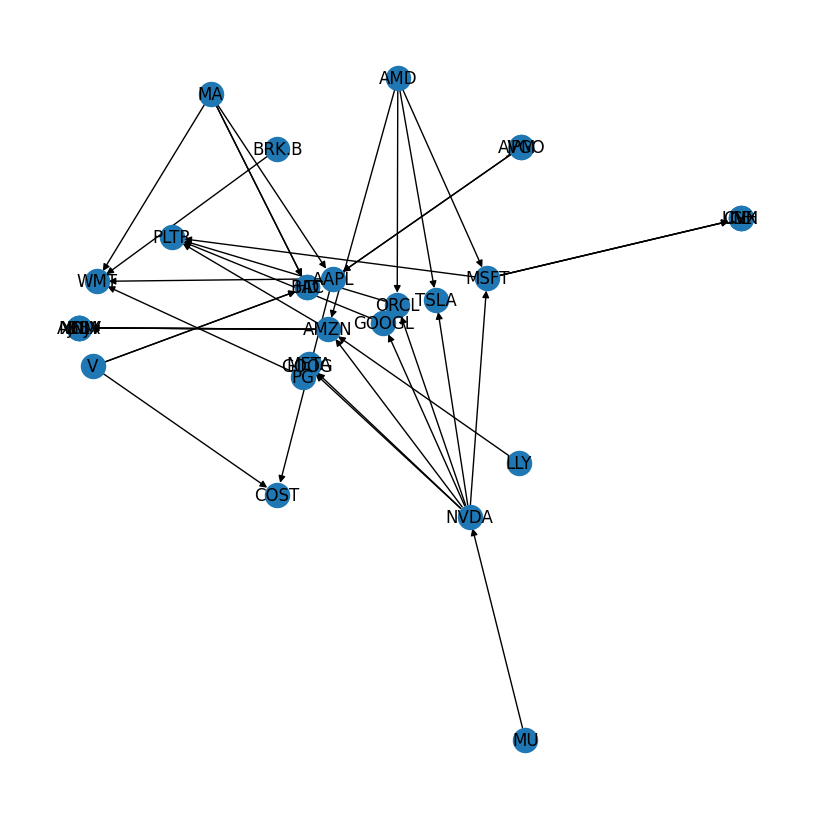

In [4]:
plt.figure(figsize=[8, 8])
layout = nx.kamada_kawai_layout(G1)
nx.draw(G1, layout, with_labels=True)

# Actividad

 ¿qué se puede decir de los vértices de mayor centralidad? ¿Tiene sentido? ¿Qué se puede decir de la centralidad de sus vecinos? ¿En qué cambian? ¿Cómo se comparan con los vértices obtenidos en la actividad de centralidad de grado y de eigenvector? Para los vértices que bajan o suben de centralidad, ¿qué se puede decir de sus vecinos?




In [8]:
def safe_katz_centrality(G, alpha=0.5, step=0.01):
    while alpha > 0:
        try:
            return nx.katz_centrality(G, alpha=alpha, tol=0.01), alpha
        except Exception:
            alpha -= step

    raise ValueError("Katz centrality did not converge for any positive alpha.")

deg_centralidades = nx.degree_centrality(G1)
eig_centralidades = nx.eigenvector_centrality(G1, tol=0.01)
katz_centralidades, katz_alpha = safe_katz_centrality(G1, alpha=1)
print(f"Convergio con un alpha={katz_alpha:.4f}")
pg_centralidades = nx.pagerank(G1)


def sum1_dict(d):
    s = sum(d.values())
    return {k: (v / s if s != 0 else 0.0) for k, v in d.items()}


deg_centralidades = sum1_dict(deg_centralidades)
eig_centralidades = sum1_dict(eig_centralidades)
katz_centralidades = sum1_dict(katz_centralidades)
pg_centralidades = sum1_dict(pg_centralidades)


eig_sizes = np.array([eig_centralidades[n] for n in G1])
deg_colors = np.array([deg_centralidades[i] for i in G1])
pg_sizes = np.array([pg_centralidades[n] for n in G1])
katz_colors = np.array([katz_centralidades[i] for i in G1])


Convergio con un alpha=1.0000


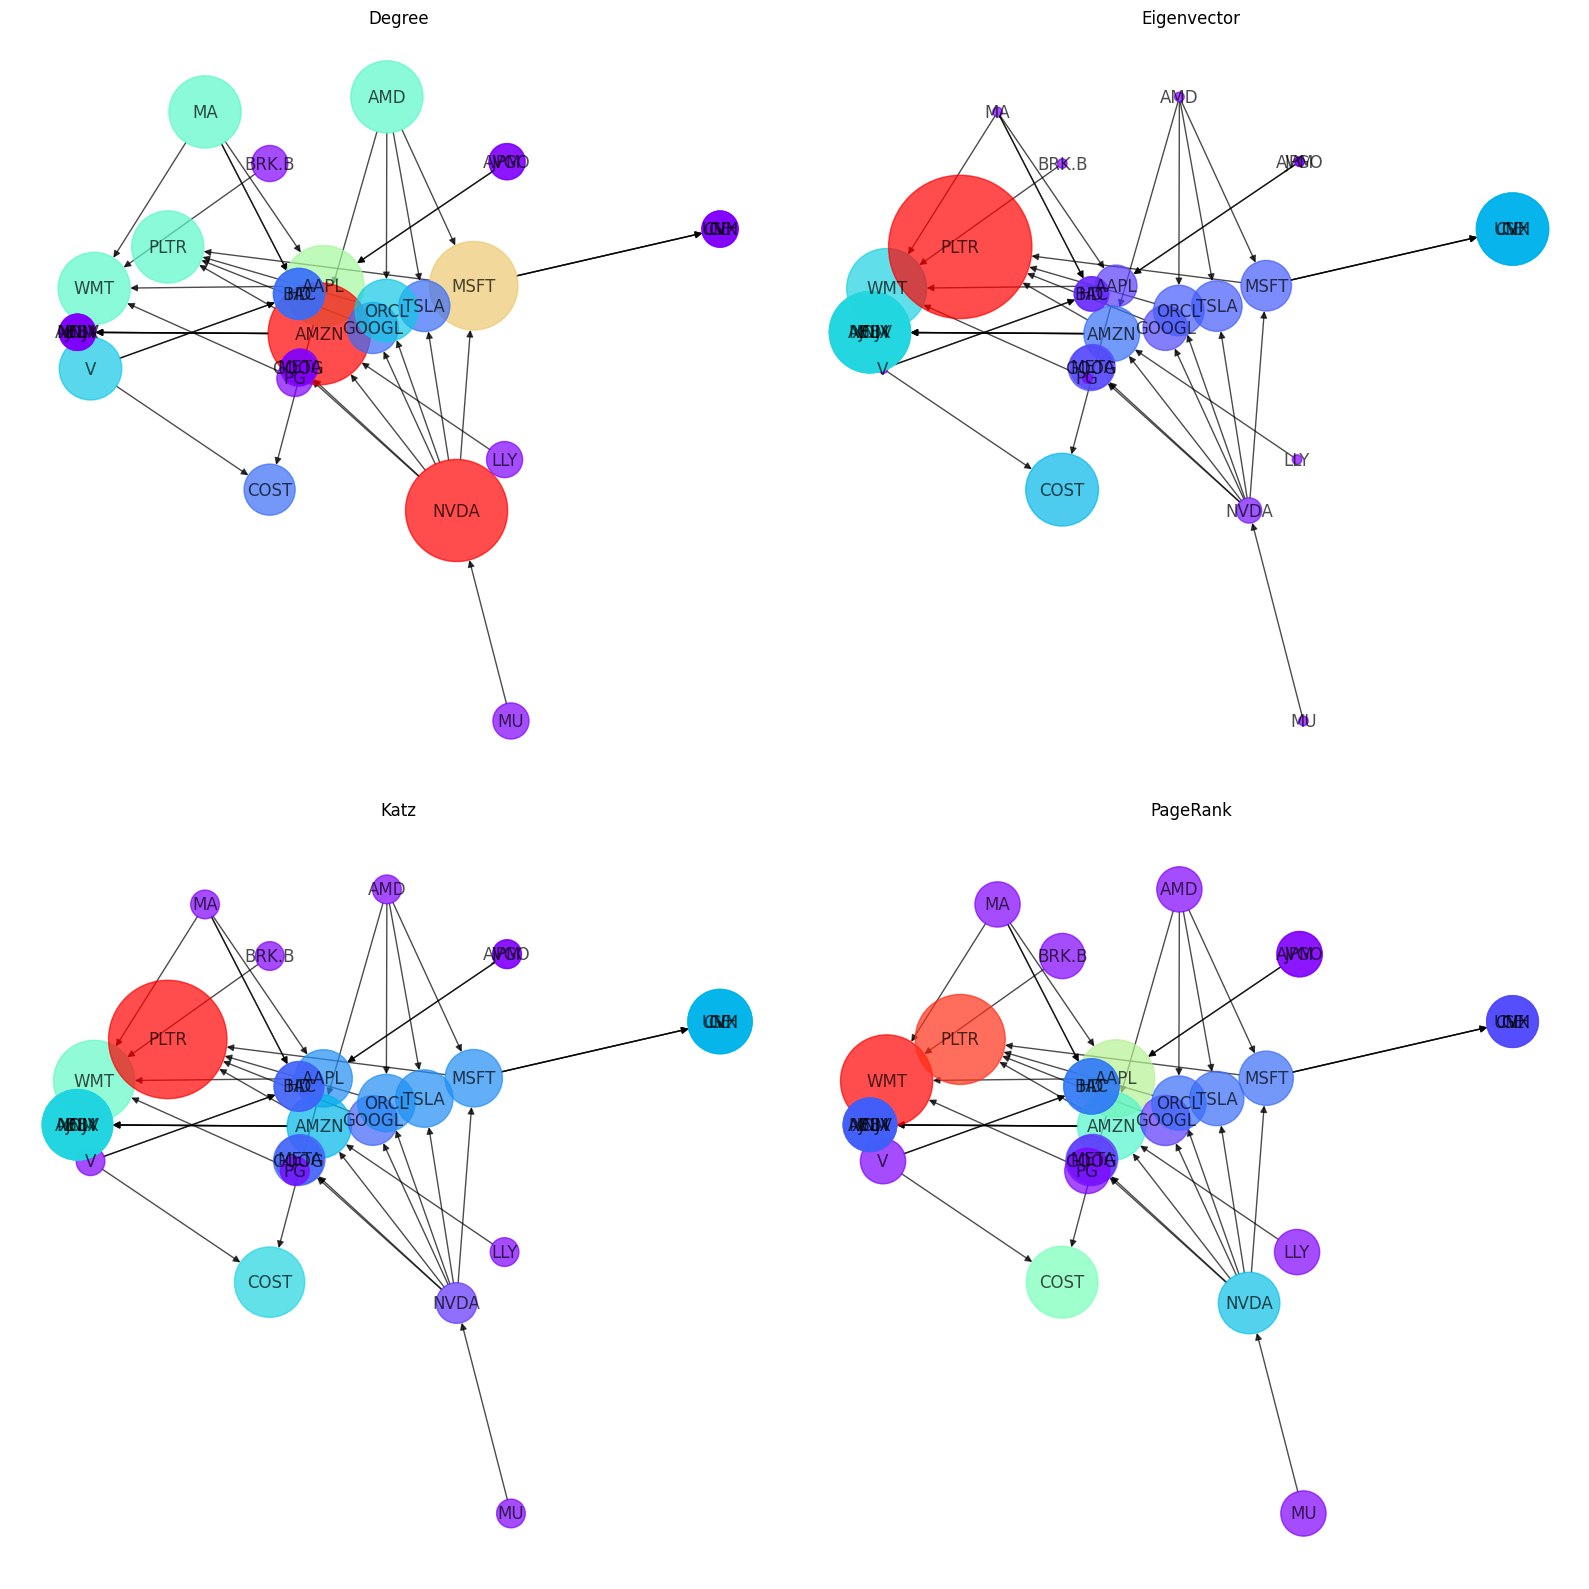

In [9]:
plt.figure(figsize=(16, 16))

nsize = 50000

plt.subplot(2, 2, 1)
nx.draw_kamada_kawai(G1, node_size=nsize*deg_colors,
                     node_color=deg_colors, with_labels=True, alpha=0.7)
plt.title("Degree")

plt.subplot(2, 2, 2)
nx.draw_kamada_kawai(G1, node_size=nsize*eig_sizes,
                     node_color=eig_sizes, with_labels=True, alpha=0.7)
plt.title("Eigenvector")
    
plt.subplot(2, 2, 3)
nx.draw_kamada_kawai(G1, node_size=nsize*katz_colors,
                     node_color=katz_colors, with_labels=True, alpha=0.7)
plt.title("Katz")

plt.subplot(2, 2, 4)
nx.draw_kamada_kawai(G1, node_size=nsize*pg_sizes,
                     node_color=pg_sizes, with_labels=True, alpha=0.7)
plt.title("PageRank")

plt.tight_layout()
plt.show()

## Funciones


In [10]:
k = 10

top_deg = [n for n, v in sorted(
    deg_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_eig = [n for n, v in sorted(
    eig_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_katz = [n for n, v in sorted(
    katz_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_pg = [n for n, v in sorted(
    pg_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]

In [11]:
# plot centralidades

def plot_centralidades(top_pos, title: str = '', nodesize=10000):
    top_pos_eig = np.array([eig_centralidades[n] for n in top_pos])
    top_pos_deg = np.array([deg_centralidades[n] for n in top_pos])
    top_pos_katz = np.array([katz_centralidades[n] for n in top_pos])
    top_pos_pg = np.array([pg_centralidades[n] for n in top_pos])

    plt.figure(figsize=(16, 16))
    pos = nx.kamada_kawai_layout(G1)

    plt.subplot(2, 2, 2)
    nx.draw_networkx_edges(G1, pos, alpha=0.15, width=1.0)
    nx.draw_networkx_nodes(G1, pos, nodelist=top_pos, node_size=nodesize*top_pos_eig,
                           node_color=top_pos_eig, alpha=0.6)
    nx.draw_networkx_labels(
        G1, pos, labels={n: n for n in top_pos}, font_size=10)
    plt.title("Eigenvector")
    plt.axis("off")

    plt.subplot(2, 2, 1)
    nx.draw_networkx_edges(G1, pos, alpha=0.15, width=1.0)
    nx.draw_networkx_nodes(G1, pos, nodelist=top_pos, node_size=nodesize*top_pos_deg,
                           node_color=top_pos_deg, alpha=0.6)
    nx.draw_networkx_labels(
        G1, pos, labels={n: n for n in top_pos}, font_size=10)
    plt.title("Degree")
    plt.axis("off")

    plt.subplot(2, 2, 3)
    nx.draw_networkx_edges(G1, pos, alpha=0.15, width=1.0)
    nx.draw_networkx_nodes(G1, pos, nodelist=top_pos, node_size=nodesize*top_pos_katz,
                           node_color=top_pos_katz, alpha=0.6)
    nx.draw_networkx_labels(
        G1, pos, labels={n: n for n in top_pos}, font_size=10)
    plt.title("Katz")
    plt.axis("off")

    plt.subplot(2, 2, 4)
    nx.draw_networkx_edges(G1, pos, alpha=0.15, width=1.0)
    nx.draw_networkx_nodes(G1, pos, nodelist=top_pos, node_size=nodesize*top_pos_pg,
                           node_color=top_pos_pg, alpha=0.6)
    nx.draw_networkx_labels(
        G1, pos, labels={n: n for n in top_pos}, font_size=10)
    plt.title("PageRank")
    plt.axis("off")

    plt.suptitle(title, fontsize=20)
    plt.tight_layout()
    plt.show()

In [12]:
# tabla

def tabla(top_pos, digits):
    df = (
        pd.DataFrame({
            "node": top_pos,
            "Degree": [deg_centralidades[n] for n in top_pos],
            "Eigenvector": [eig_centralidades[n] for n in top_pos],
            "Katz": [katz_centralidades[n] for n in top_pos],
            "PageRank": [pg_centralidades[n] for n in top_pos],
        })
        .reset_index(drop=True)
    )


    display(
        df.style.format(
            {
                "Eigenvector": f"{{:.{digits}f}}",
                "Degree": f"{{:.{digits}f}}",
                "PageRank": f"{{:.{digits}f}}",
                "Katz": f"{{:.{digits}f}}",
            }
        )
    )
    return df

In [13]:
# vecinos

import matplotlib


def ego_layers(G, center, max_radius):
    layers = []
    prev = set()
    for r in range(0, max_radius + 1):
        nodes_r = set(nx.ego_graph(G, center, radius=r).nodes())
        layers.append(nodes_r - prev)  # exactly distance r
        prev = nodes_r
    return layers  # [L0, L1, ..., Lmax]


def layer_color_map(layers, cmap_name="Reds", stops=None, default="lightgray"):
    # stops: list of floats in [0,1] for each layer (0..R). Higher => darker in Reds.
    if stops is None:
        # for radius 3: [dark, ..., light]
        stops = np.linspace(0.95, 0.35, num=len(layers))

    cmap = matplotlib.colormaps[cmap_name]
    layer_to_color = {i: cmap(stops[i]) for i in range(len(layers))}

    node_to_layer = {}
    for i, L in enumerate(layers):
        for n in L:
            node_to_layer[n] = i

    def colors_for(subG):
        cols = []
        for n in subG.nodes():
            i = node_to_layer.get(n, None)
            cols.append(
                layer_to_color[i] if i is not None else mcolors.to_rgba(default))
        return cols

    return colors_for


def plot_ego_radii_3panel(G, center, radii=(1, 2, 3), layout="kamada_kawai", figsize=(18, 6)):
    max_r = max(radii)
    layers = ego_layers(G, center, max_r)          # L0..Lmax (exact distance)
    colors_for = layer_color_map(layers, cmap_name="Reds")

    plt.figure(figsize=figsize)
    for i, r in enumerate(radii, start=1):
        SG = nx.ego_graph(G, center, radius=r)

        n_nodes = SG.number_of_nodes()
        n_edges = SG.number_of_edges()
        density = nx.density(SG) if n_nodes > 1 else 0.0

        # how many nodes at each exact distance from center (up to r)
        layer_counts = [len(layers[d]) for d in range(r + 1)]
        # neighbors in each step (excluding the center at distance 0)
        neighbor_counts = layer_counts[1:]  # distances 1..r

        plt.subplot(1, 3, i)
        if layout == "circular":
            pos = nx.circular_layout(SG)
            nx.draw(SG, pos, node_color=colors_for(
                SG), with_labels=True, font_size=8)
        else:
            nx.draw_kamada_kawai(SG, node_color=colors_for(
                SG), with_labels=True, font_size=8)

        plt.title(
            f"Nodo {center} (radio={r})\n"
            f"Nodos={n_nodes}, Aristas={n_edges}, Densidad={density:.3f}\n"
            f"Vecinos por distancia={neighbor_counts}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()


def plot_ego_radii_4panel(G, center, radii=(1, 2, 3, 4), layout="kamada_kawai", figsize=(24, 6)):
    max_r = max(radii)
    layers = ego_layers(G, center, max_r)
    colors_for = layer_color_map(layers, cmap_name="Reds")

    plt.figure(figsize=figsize)
    for i, r in enumerate(radii, start=1):
        SG = nx.ego_graph(G, center, radius=r)

        n_nodes = SG.number_of_nodes()
        n_edges = SG.number_of_edges()
        density = nx.density(SG) if n_nodes > 1 else 0.0

        layer_counts = [len(layers[d]) for d in range(r + 1)]
        neighbor_counts = layer_counts[1:]

        plt.subplot(1, 4, i)
        if layout == "circular":
            pos = nx.circular_layout(SG)
            nx.draw(SG, pos, node_color=colors_for(
                SG), with_labels=True, font_size=8)
        else:
            nx.draw_kamada_kawai(SG, node_color=colors_for(
                SG), with_labels=True, font_size=8)

        plt.title(
            f"Nodo {center} (radio={r})\n"
            f"Nodos={n_nodes}, Aristas={n_edges}, Densidad={density:.3f}\n"
            f"Vecinos por distancia={neighbor_counts}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Top Grado

In [14]:
df_top_deg = tabla(top_deg, digits=4)

,node,Degree,Eigenvector,Katz,PageRank
0,NVDA,0.1081,0.0066,0.0171,0.0393
1,AMZN,0.1081,0.0322,0.0427,0.0485
2,MSFT,0.0811,0.0265,0.0342,0.0305
3,AAPL,0.0676,0.0180,0.0342,0.0618
4,MA,0.0541,0.0009,0.0085,0.0212
5,WMT,0.0541,0.0662,0.0684,0.0881
6,PLTR,0.0541,0.2129,0.1453,0.0840
7,AMD,0.0541,0.0009,0.0085,0.0212
8,V,0.0405,0.0009,0.0085,0.0212
9,ORCL,0.0405,0.0265,0.0342,0.0305


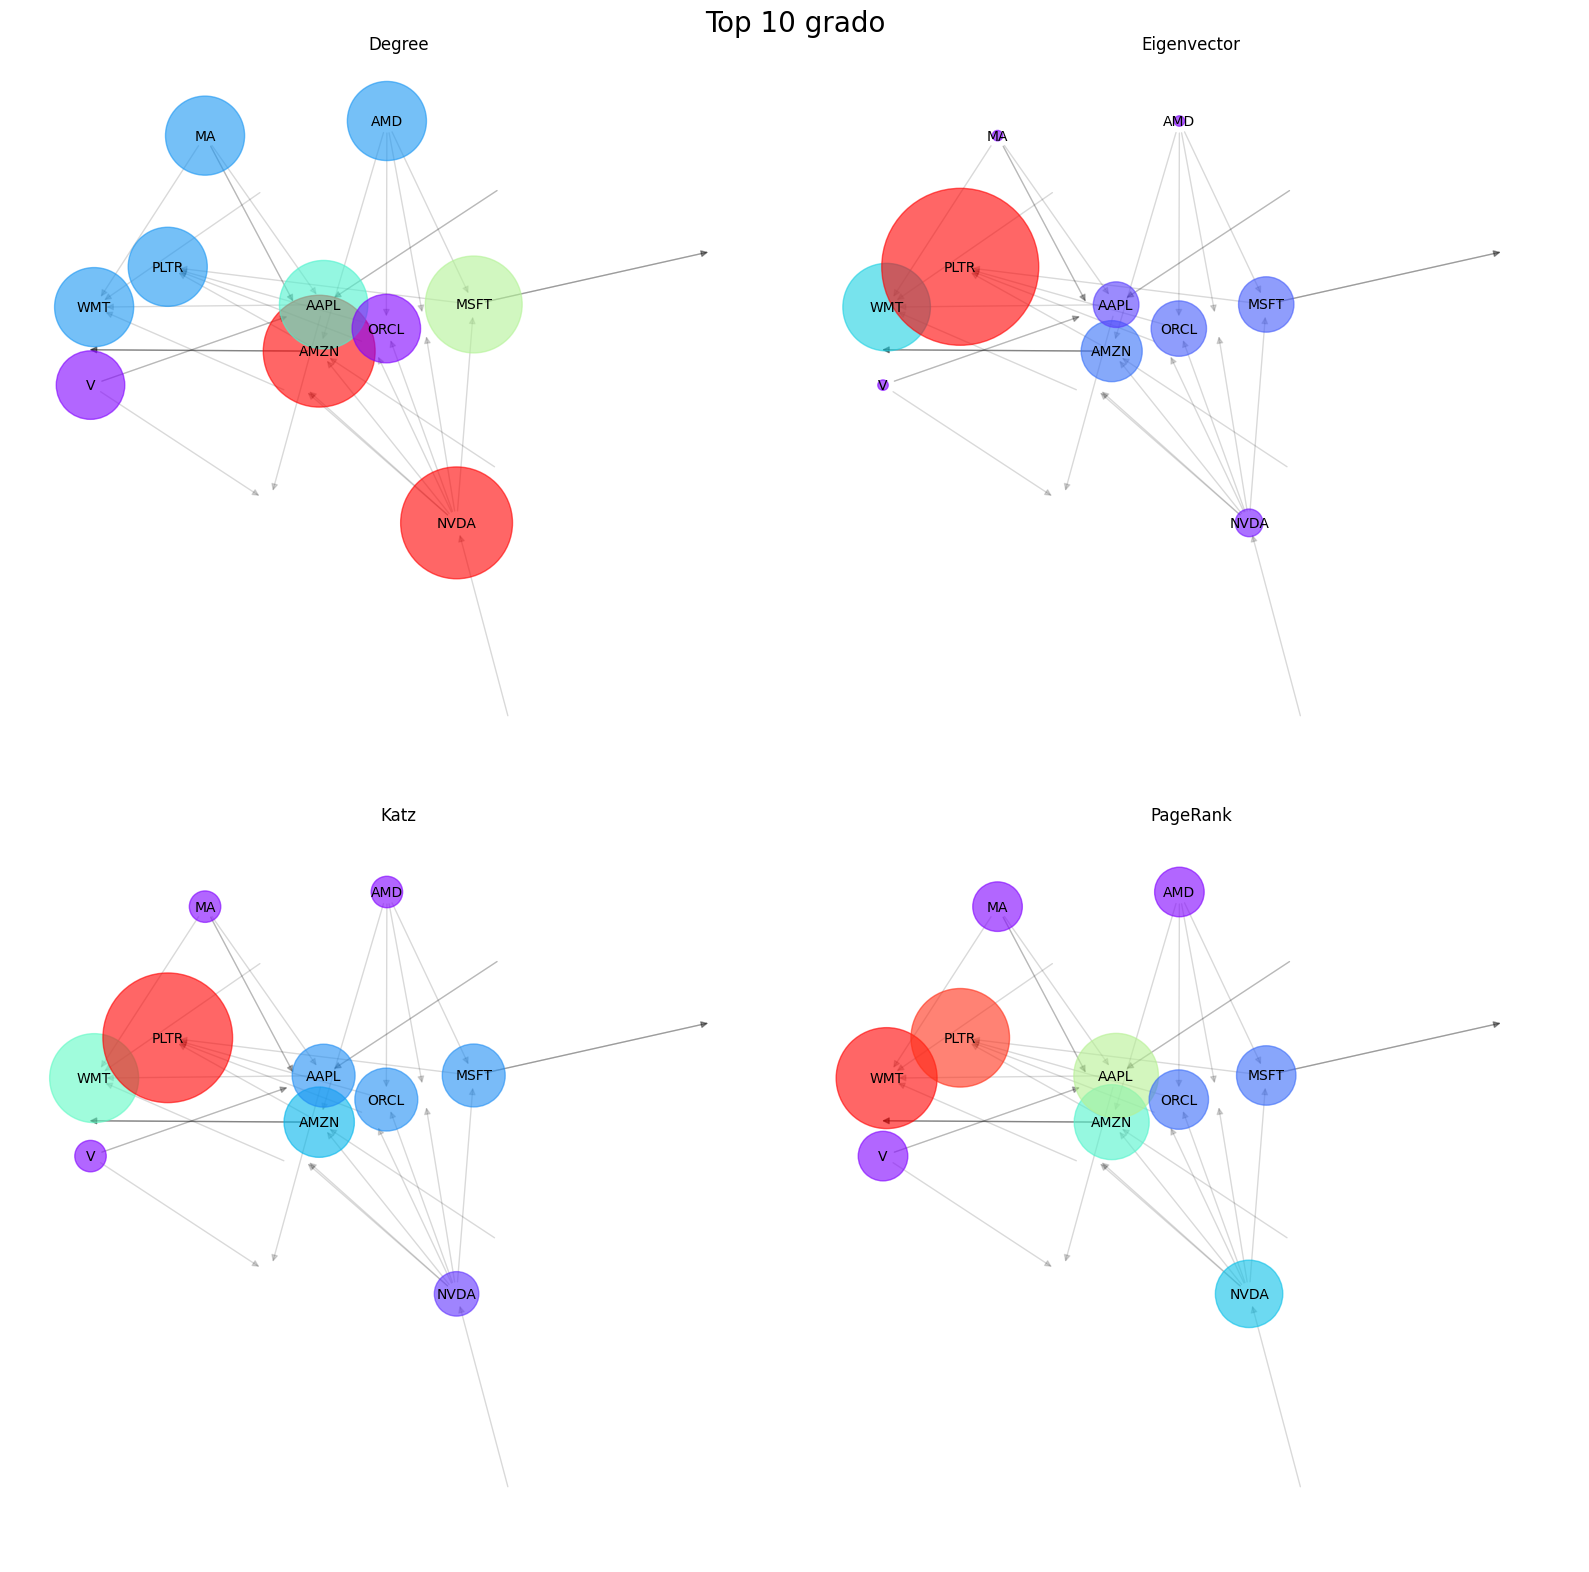

In [15]:
plot_centralidades(
    top_pos=top_deg, title='Top 10 grado', nodesize=60000)

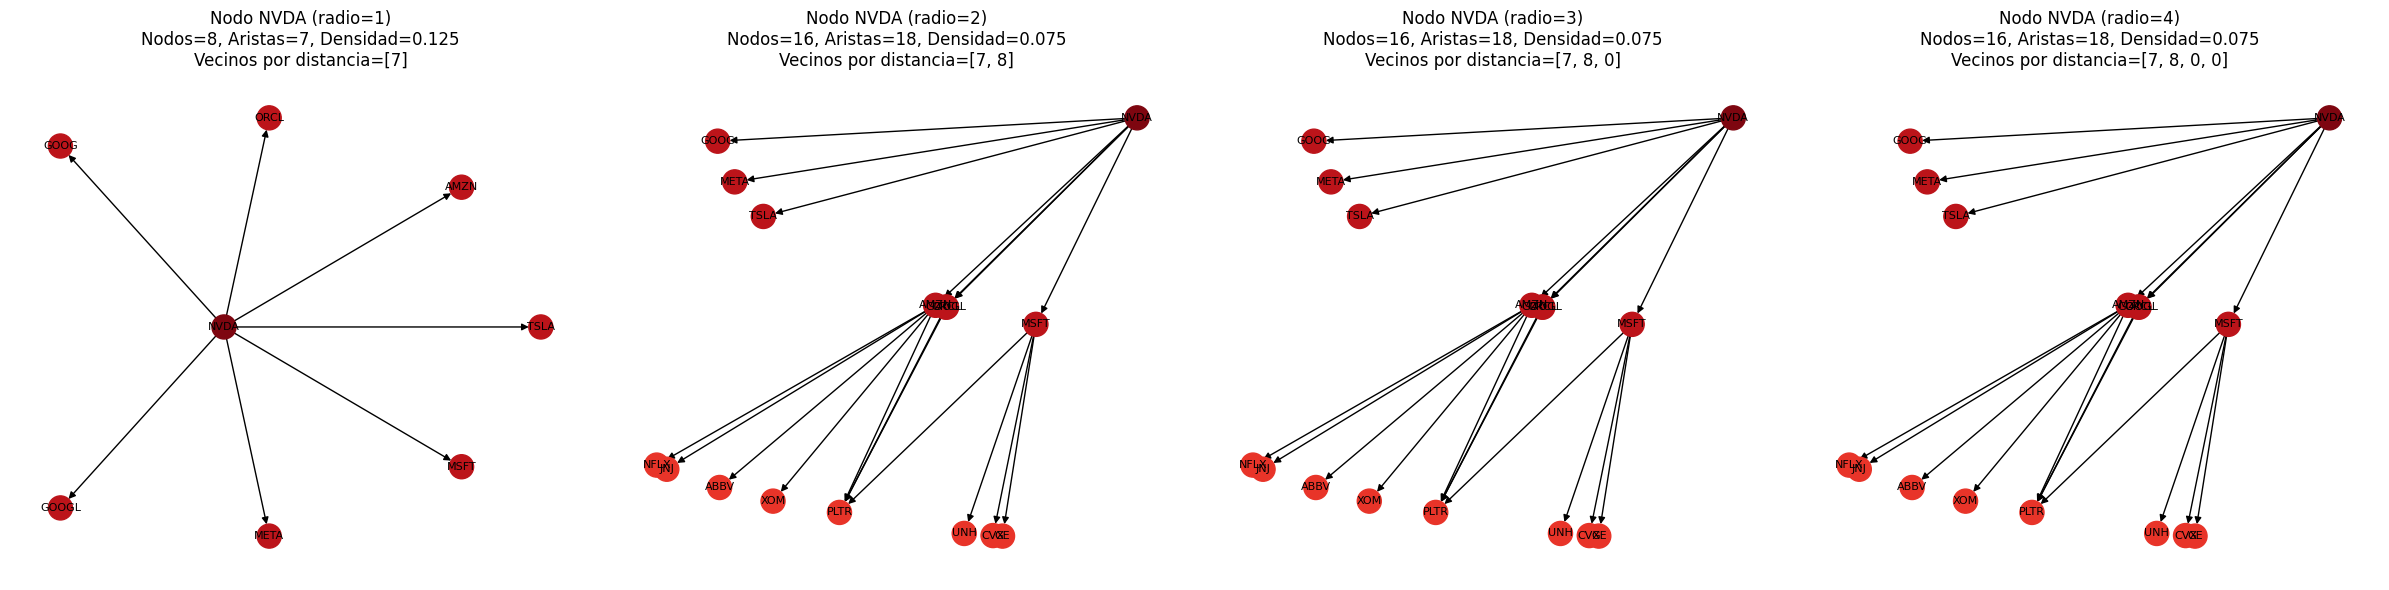

In [16]:
maxpos_node, maxpos_val = max(deg_centralidades.items(), key=lambda kv: kv[1])
plot_ego_radii_4panel(G1, maxpos_node, radii=(
    1, 2, 3, 4), layout="kamada_kawai")

## Top Eigenvector

In [17]:
df_top_eig = tabla(top_eig, digits=4)

,node,Degree,Eigenvector,Katz,PageRank
0,PLTR,0.0541,0.2129,0.1453,0.0840
1,XOM,0.0135,0.0681,0.0513,0.0295
2,JNJ,0.0135,0.0681,0.0513,0.0295
3,ABBV,0.0135,0.0681,0.0513,0.0295
4,NFLX,0.0135,0.0681,0.0513,0.0295
5,WMT,0.0541,0.0662,0.0684,0.0881
6,COST,0.0270,0.0549,0.0513,0.0535
7,GE,0.0135,0.0539,0.0427,0.0277
8,CVX,0.0135,0.0539,0.0427,0.0277
9,UNH,0.0135,0.0539,0.0427,0.0277


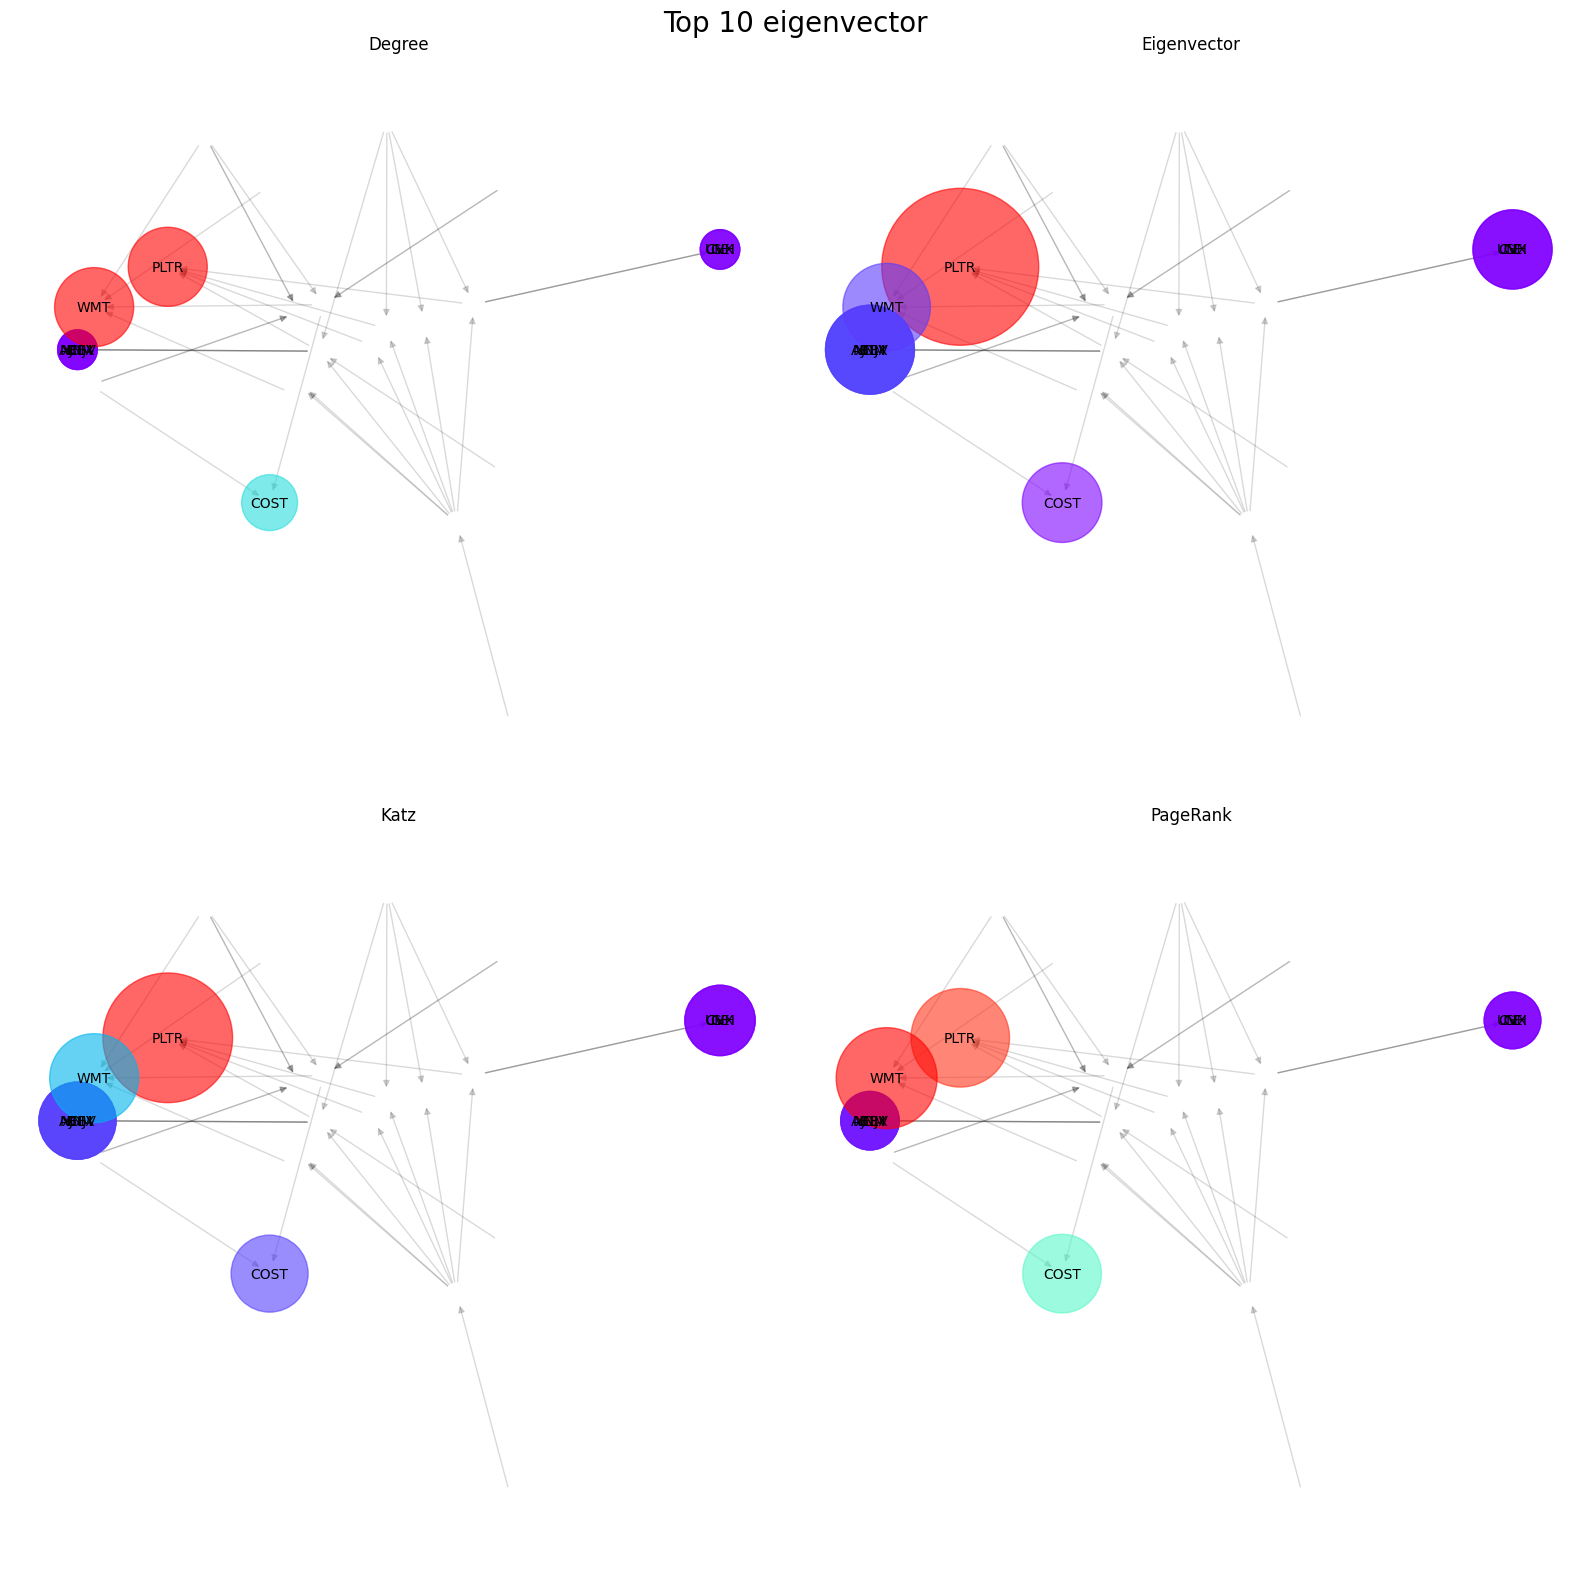

In [18]:
plot_centralidades(
    top_pos=top_eig, title='Top 10 eigenvector', nodesize=60000)

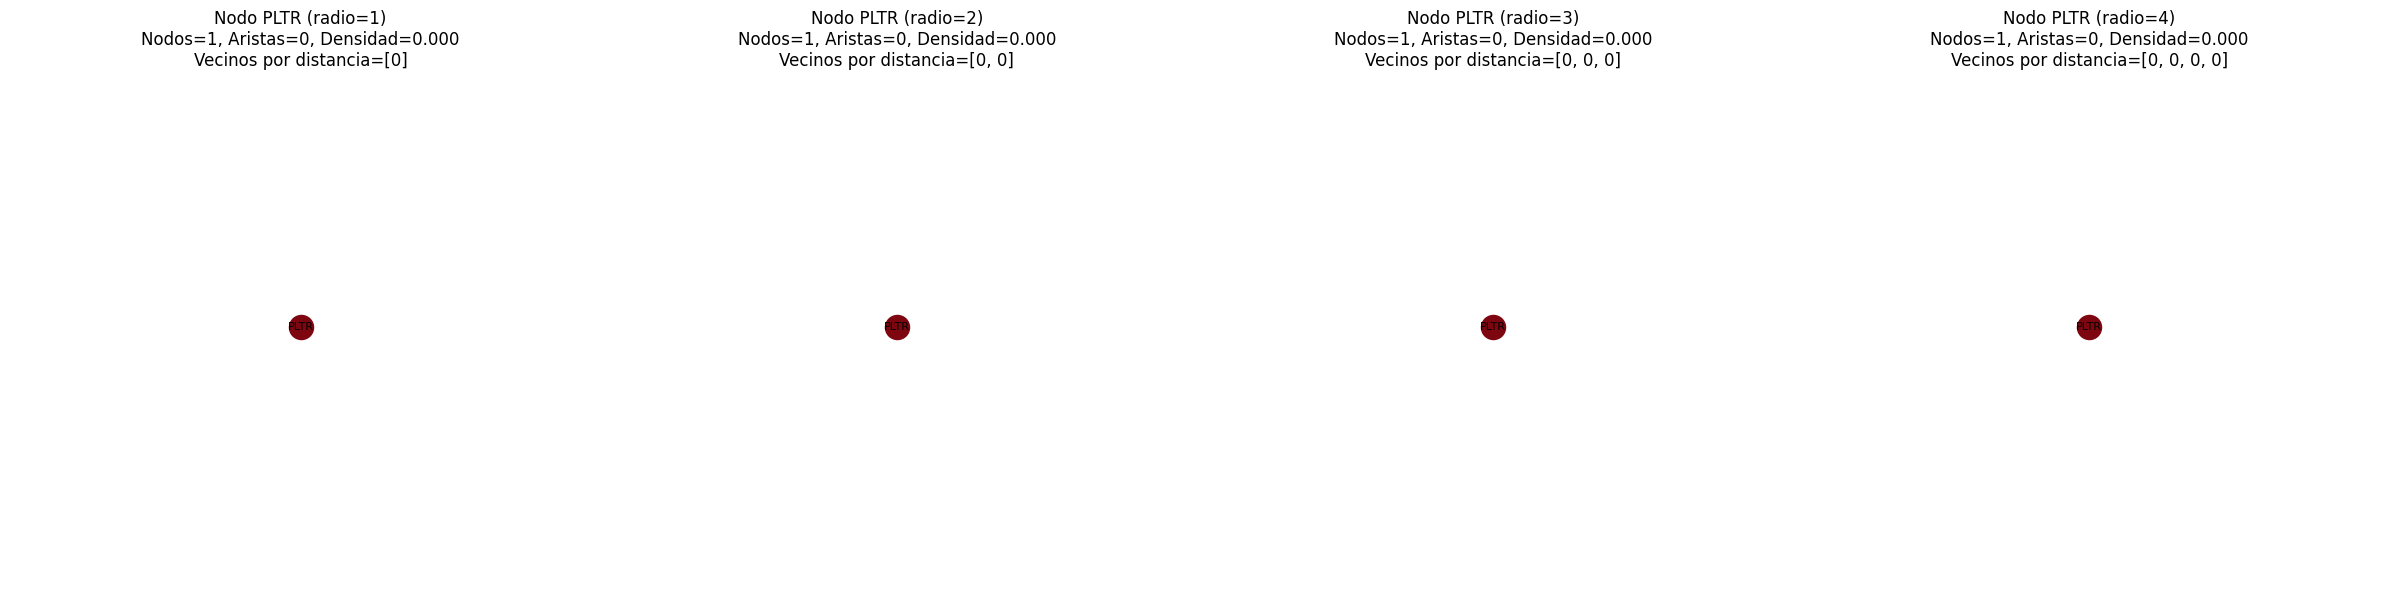

In [19]:
maxpos_node, maxpos_val = max(eig_centralidades.items(), key=lambda kv: kv[1])
plot_ego_radii_4panel(G1, maxpos_node, radii=(
    1, 2, 3, 4), layout="kamada_kawai")

## Top Katz

In [20]:
df_top_katz = tabla(top_katz, digits=4)

,node,Degree,Eigenvector,Katz,PageRank
0,PLTR,0.0541,0.2129,0.1453,0.0840
1,WMT,0.0541,0.0662,0.0684,0.0881
2,COST,0.0270,0.0549,0.0513,0.0535
3,XOM,0.0135,0.0681,0.0513,0.0295
4,JNJ,0.0135,0.0681,0.0513,0.0295
5,ABBV,0.0135,0.0681,0.0513,0.0295
6,NFLX,0.0135,0.0681,0.0513,0.0295
7,AMZN,0.1081,0.0322,0.0427,0.0485
8,GE,0.0135,0.0539,0.0427,0.0277
9,CVX,0.0135,0.0539,0.0427,0.0277


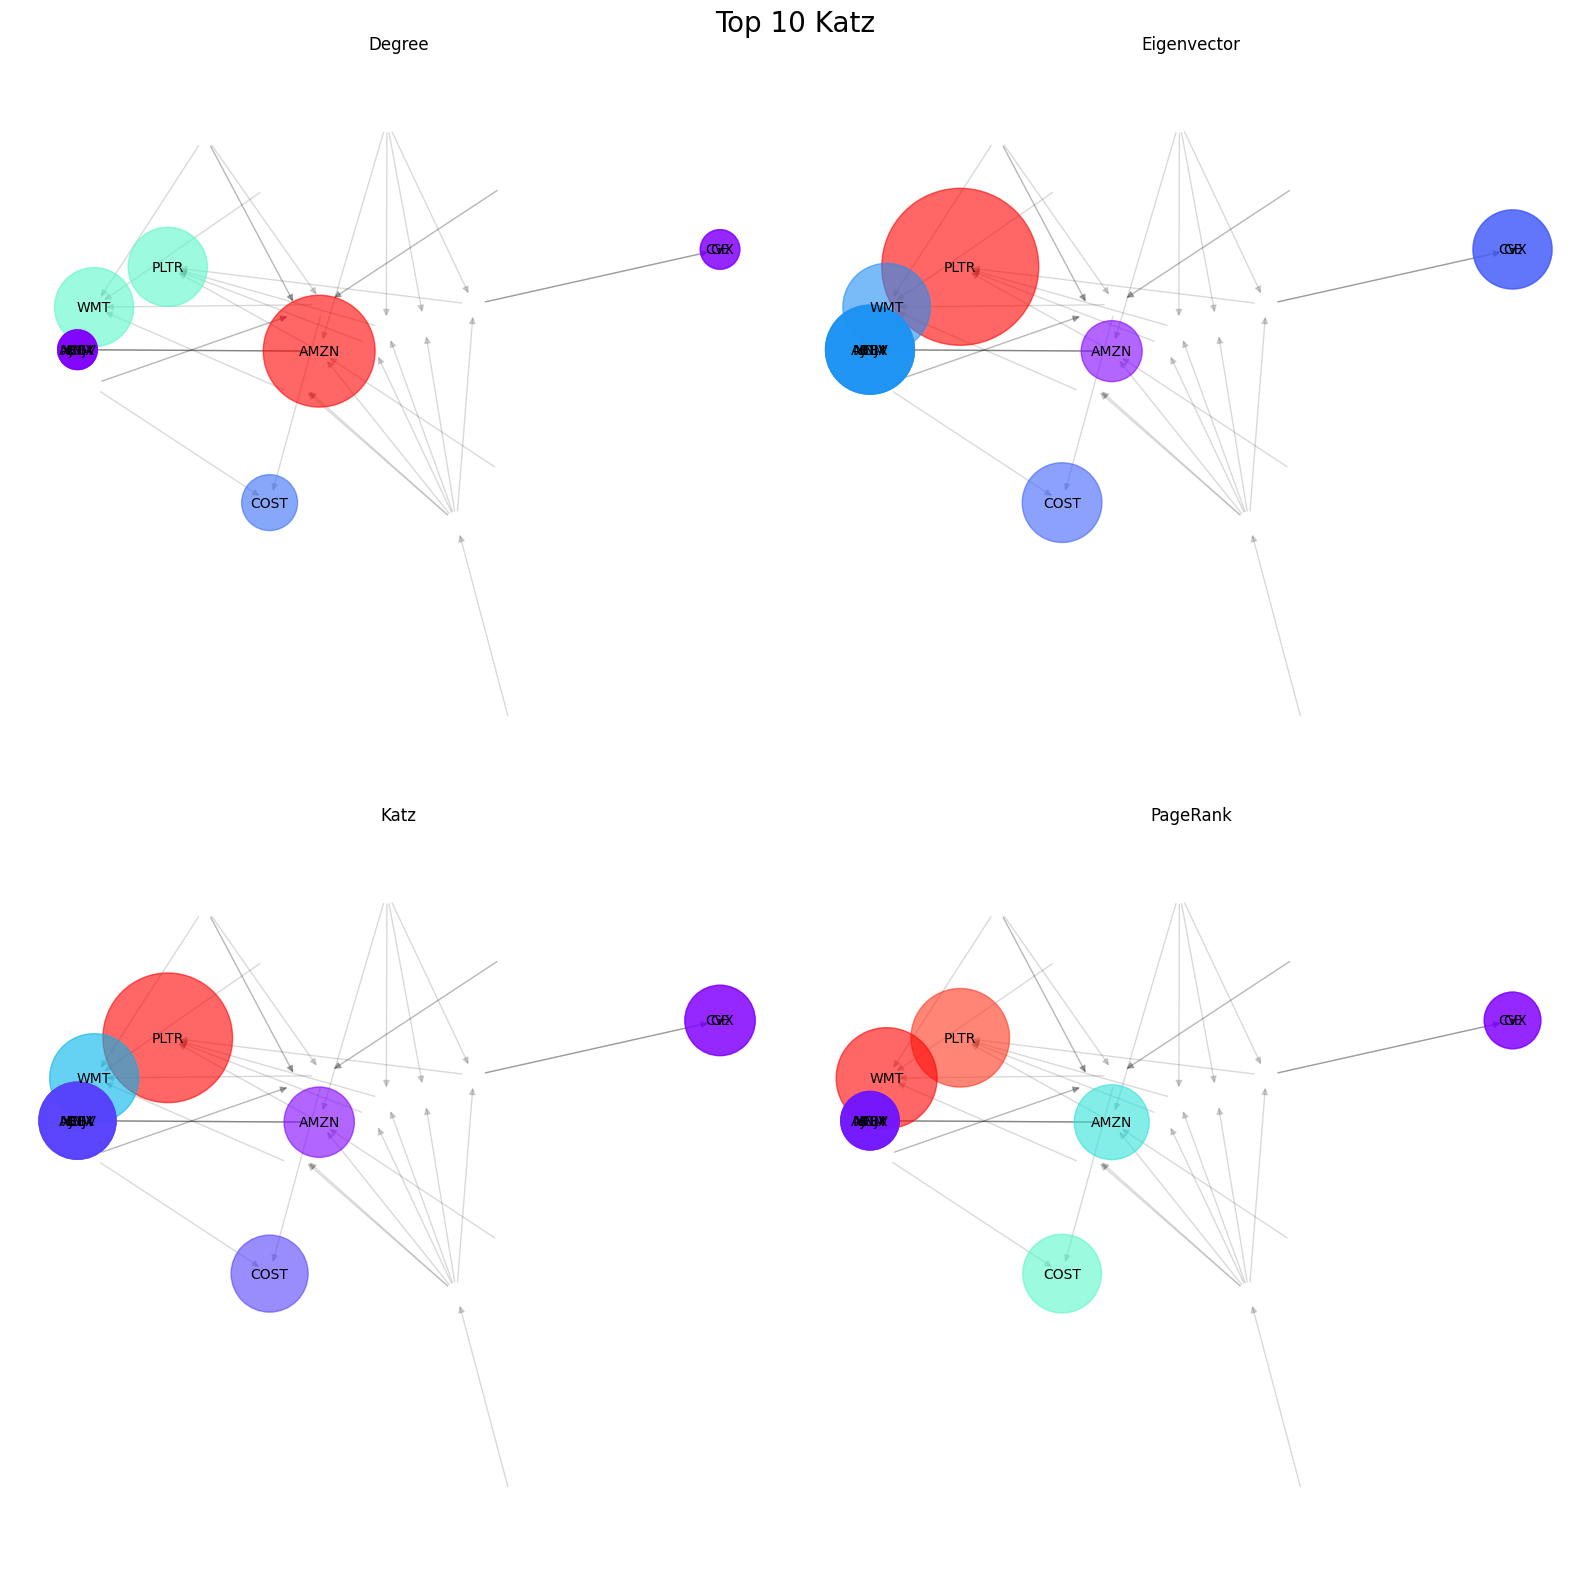

In [21]:
plot_centralidades(
    top_pos=top_katz, title='Top 10 Katz', nodesize=60000)

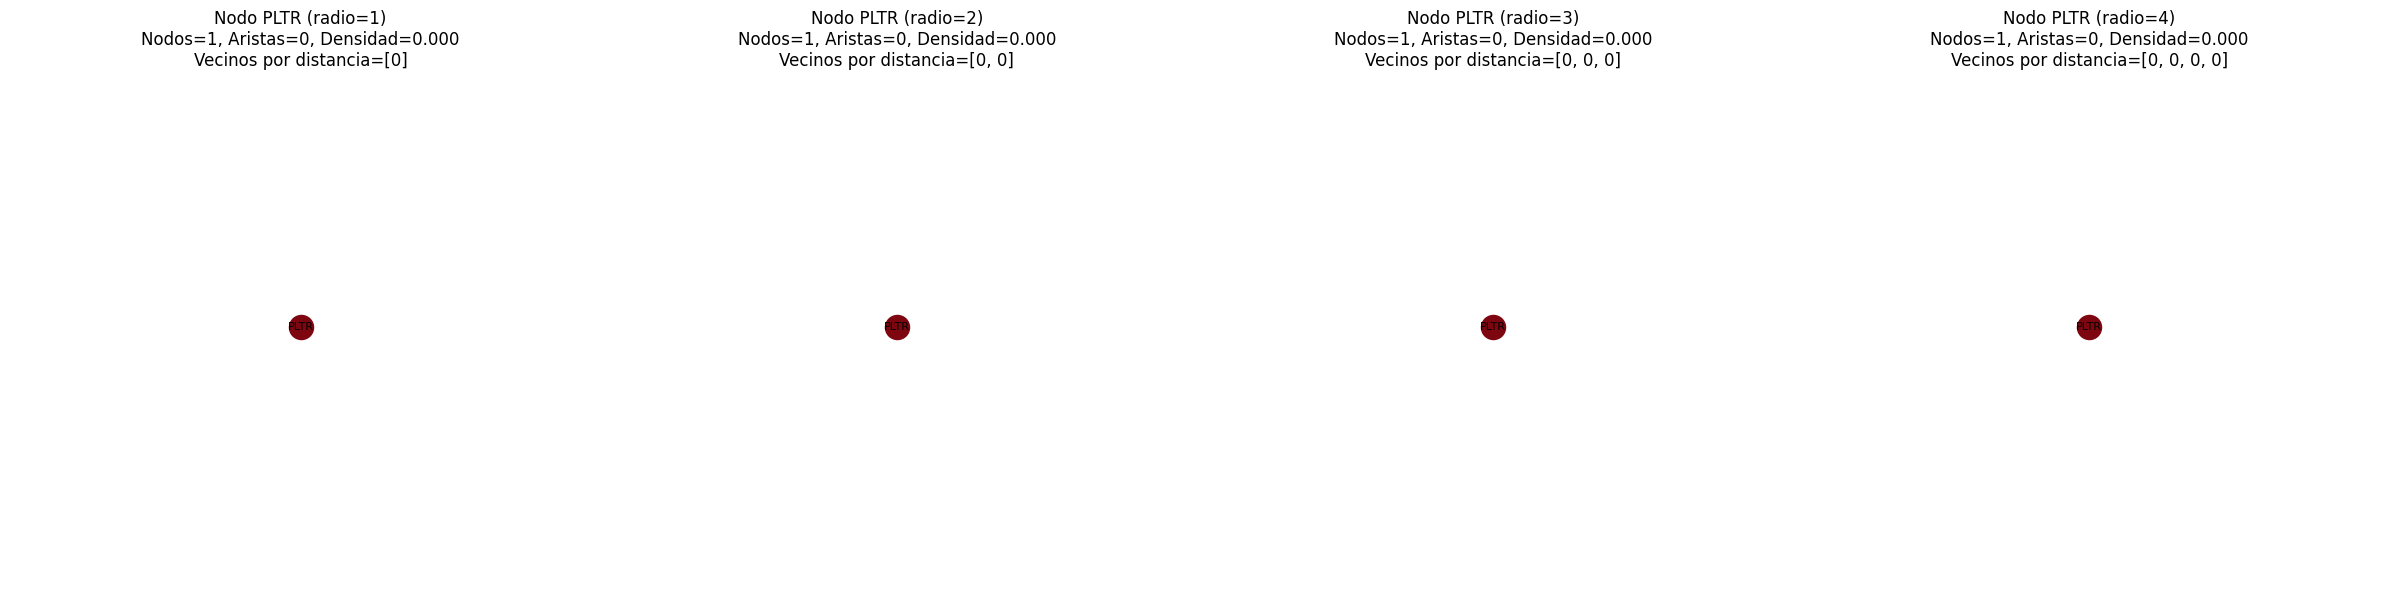

In [22]:
maxpos_node, maxpos_val = max(katz_centralidades.items(), key=lambda kv: kv[1])
plot_ego_radii_4panel(G1, maxpos_node, radii=(
    1, 2, 3, 4), layout="kamada_kawai")

## Top PageRank

In [23]:
df_top_pg = tabla(top_pg, digits=4)

,node,Degree,Eigenvector,Katz,PageRank
0,WMT,0.0541,0.0662,0.0684,0.0881
1,PLTR,0.0541,0.2129,0.1453,0.0840
2,AAPL,0.0676,0.0180,0.0342,0.0618
3,COST,0.0270,0.0549,0.0513,0.0535
4,AMZN,0.1081,0.0322,0.0427,0.0485
5,NVDA,0.1081,0.0066,0.0171,0.0393
6,BAC,0.0270,0.0123,0.0256,0.0317
7,HD,0.0270,0.0123,0.0256,0.0317
8,MSFT,0.0811,0.0265,0.0342,0.0305
9,TSLA,0.0270,0.0265,0.0342,0.0305


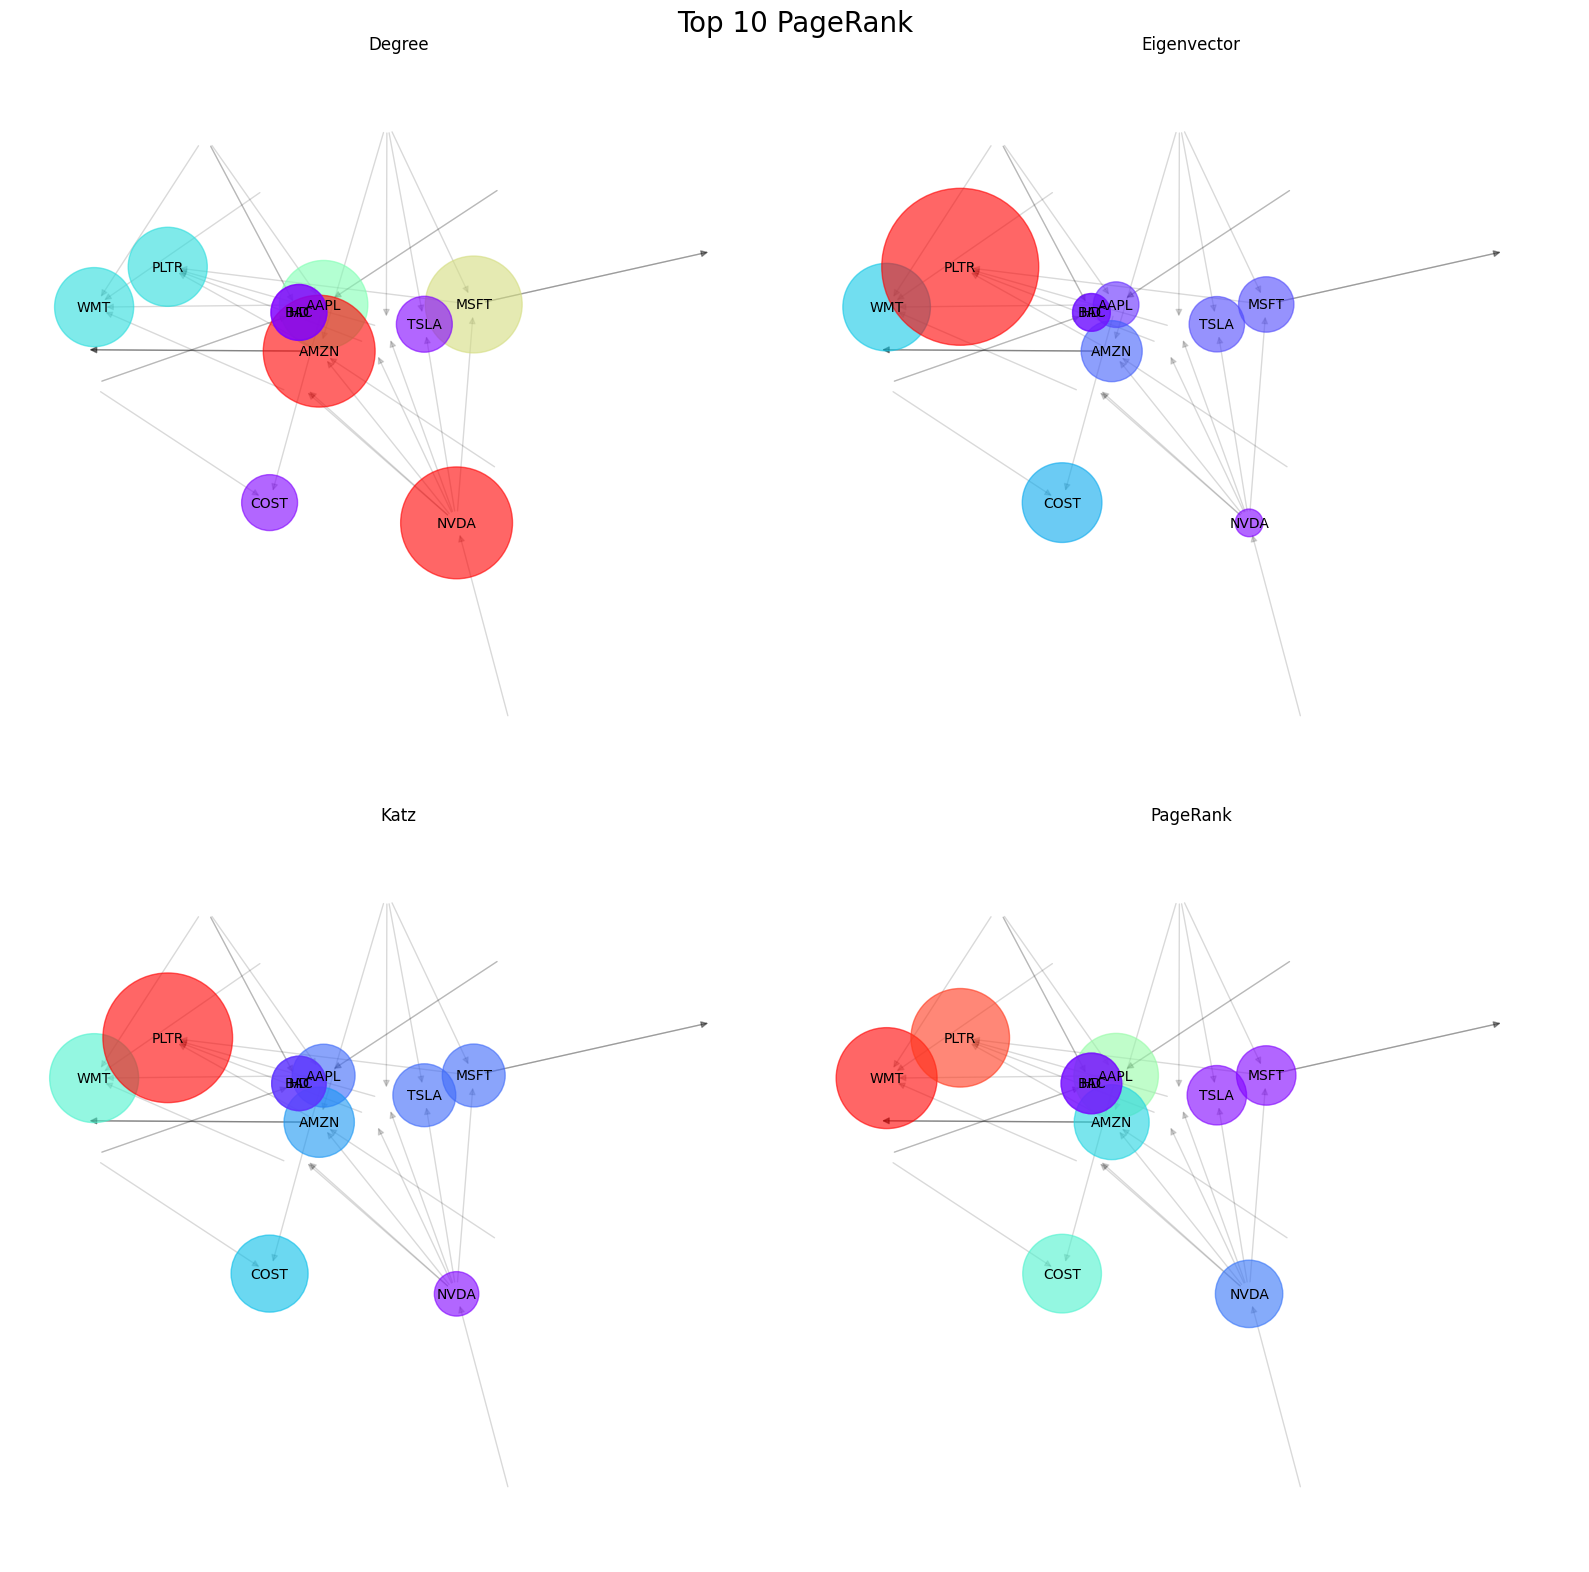

In [24]:
plot_centralidades(
    top_pos=top_pg, title='Top 10 PageRank', nodesize=60000)

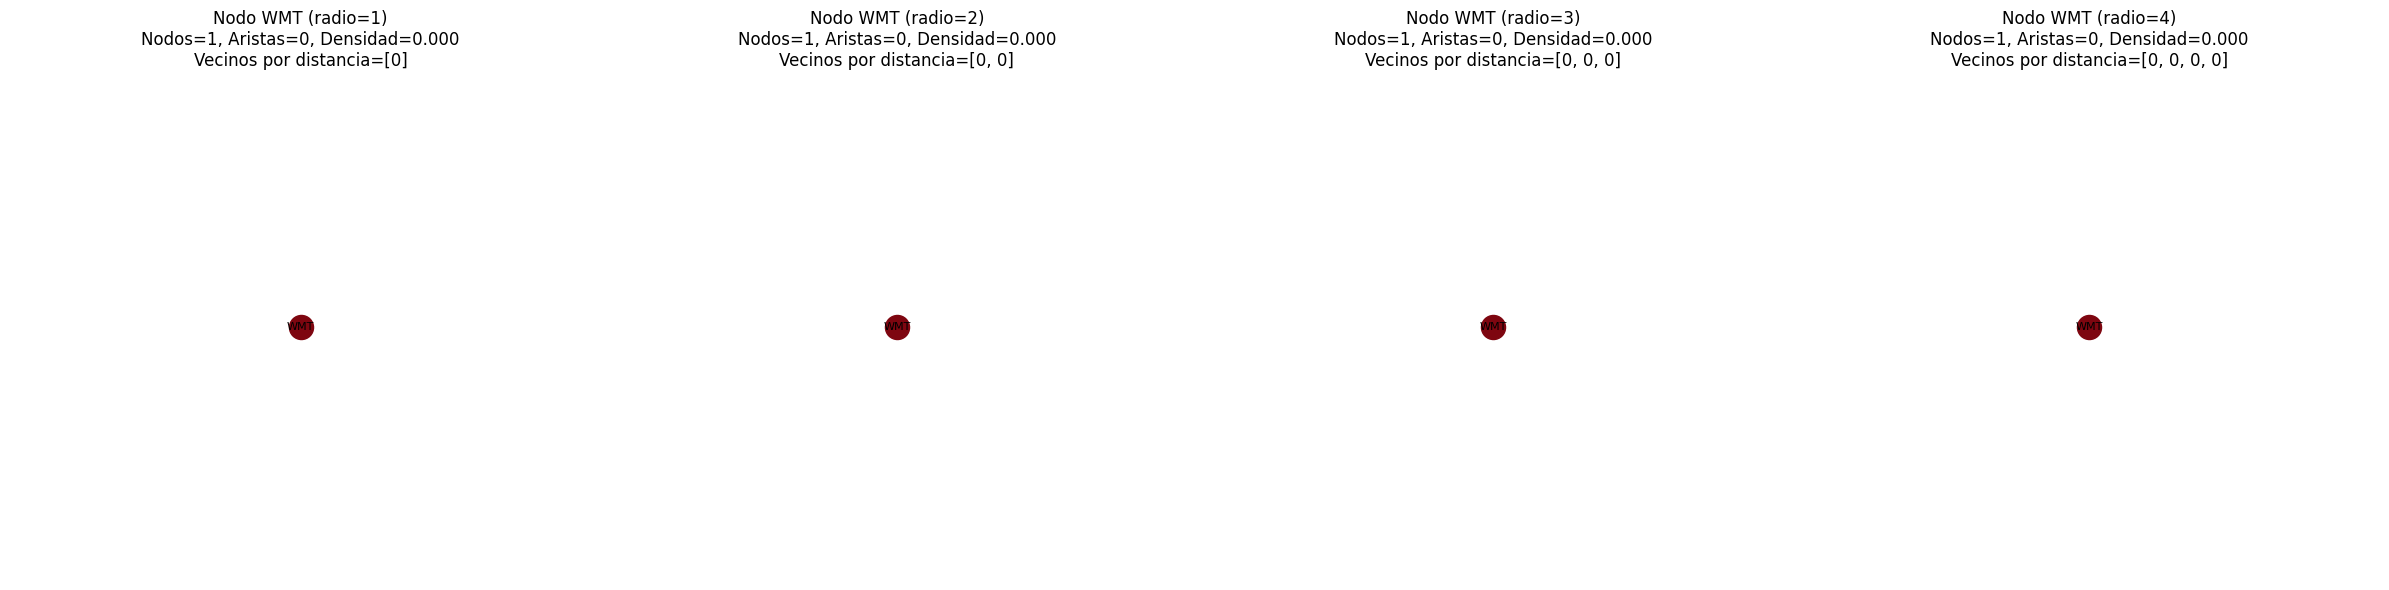

In [25]:
maxpos_node, maxpos_val = max(pg_centralidades.items(), key=lambda kv: kv[1])
plot_ego_radii_4panel(G1, maxpos_node, radii=(
    1, 2, 3, 4), layout="kamada_kawai")

# Interpretacion

Se interpretan las diferencias entre las centralidades de grado, eigenvector, Katz y PageRank. Se analizan los vértices que tienen una mayor diferencia entre estas centralidades y se discute su significado en el contexto de la red de colaboración. Se examinan los vecinos de estos vértices para entender cómo su posición en la red afecta su centralidad y cómo esto se relaciona con su papel como investigadores en la red.

Que converja con un $\alpha=1$ sugiere que la red, como sistema de “influencia por cadenas”, no tiene un nucleo denso que haga explotar la importancia al contar caminos largos. Comparado con las redes donde convergia con $\alpha$ de $0.08$–$0.09$, aqui se puede permitir que los caminos largos pesen mas sin inestabilidad numérica, por la estructura de dos componentes y sin un supernucleo que este dentro de un subconjunto.

node	Degree	Eigenvector	Katz	PageRank  
3	AAPL	0.0676	0.0000	0.0083	0.0681  
4	WMT_	0.0541	0.0000	0.0072	0.0565  
5	MA__	0.0541	0.0000	0.0078	0.0519  

Podemos ver que hay top nodos como AAPL, WMT y MA que estan en el nucleo de su componente y no tienen peso en la centralidad de eigenvector, porque en eigenvector solo tienen los de la componente mas grande (o de la que tenga un espectro mas grande) y estos 3 nodos son muy importantes en su componente.  
En todas AMZN y NVDA y MSFT son los que tienen el peso mas grande en todos los tipos de centralidad, esto porque estan en la red mas grande y son los mas conectados.

# Apendice: $\text{degree} - \text{eigenvector}$

Conseguimos las diferencias de $\text{degree} - \text{eigenvector}$, nos quedamos con las mas positivas, las mas negativas, las mas cercanas a 0 y las mas alejadas.



Conseguimos las diferencias de $\text{degree} - \text{eigenvector}$, nos quedamos con las mas positivas, las mas negativas, las mas cercanas a 0 y las mas alejadas.


## Top positivos


Como es $\text{degree} - \text{eigenvector}$ son los que tienen muchos vecinos, pero sus vecinos no son muy importantes.

- Nodo tiene muchos vecinos
- Los vecinos tienen pocos vecinos

Contagian directamente a muchos, pero no se propaga mucho


## **!!!! Solo los componentes de la subred mas grande tienen eigenvector!!!** 

## Top Negativos


Como es $\text{degree} - \text{eigenvector}$ son los que tienen vecinos muy importantes y tienen pocos vecinos, o estan muy bien posicionados, pero no por tener muchos vecinos, sino porque los vecinos de los vecinos estan muy bien posicionados

Contagian directamente a pocos, pero se propaga mucho


**ORCL solo se conecta con otras 3 empresas, pero por sus vecinos la componente mas grande de la red se completa en 3 pasos**

## Top cercanos a 0


Los nodos que tienen la menor diferencia es porque es parecido cuanto pesan sus conexiones a la calidad de los nodos a los que estan conectados. Son parecidos a una red conexa, en una red conexa la diferencia de las centralidades ponderadas es 0

Justo en sus vecinos a radio = 1, se forma un $K_3$; mientras mas avanza el radio mas se va perdiendo la red completamente conexa, pero esa es la idea. En la red que estamos usando, este es el cluster mas parecido a una red completamente conexa, como un grupo de amigos que son muy amigos entre ellos.

Su densidad deberia ser la mas alta.


**Aunque AAPL forme un grafo mas denso que AMD, AAPL esta en la segunda componente, entonces su diferencia es grande. El nodo que forma subredes mas densas de la componente mas grande es AMZN**

## Top alejados


Los que tienen la diferencia mas grande, es porque estan conectados a otros de los nodos mas importantes de la red y tienen pocas conexiones, JAJA como Hugo, que es amigo de Steve Jobs, Elon Musk y Bill Gates o no me acuerdo quien era el ultimo (Steve Jobs ya no); o son los nodos que tienen muchisimas conexiones y sus vecinos no.


**El que tiene mas diferencia de sus las coapariciones en las que aparece es Obi-Wan, es el que, en comparacion, sus coapariciones son menos significativas en relacion al total de sus coapariciones, porque sus vecinos casi no salen con mas**
